# Fase 4 - Transformer destilado en CPU

Este notebook deja listo el flujo CPU-only para el transformer. Si no hay pesos locales del modelo, la precondicion queda explicita y el resto del entrenamiento no se ejecuta.

In [1]:
from pathlib import Path
import sys

RAIZ_PROYECTO = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

from src.corpus_inmuebles import preparar_corpus_para_modelado
from src.evaluacion_modelos import (
    construir_matriz_confusion_tabla,
    construir_reporte_clasificacion,
    construir_tabla_metricas,
    dibujar_matriz_confusion_profesional,
)
from src.infraestructura_cpu import configurar_torch_cpu, relevar_hardware, sugerir_tamanio_muestra
from src.transformer_cpu import (
    NOMBRE_MODELO_TRANSFORMER,
    cargar_modelo_transformer_para_clasificacion,
    cargar_tokenizador_transformer,
    construir_mapeo_etiquetas,
    crear_dataloaders_transformer,
    cuantizar_modelo_dinamicamente,
    entrenar_transformer_en_cpu,
    predecir_con_transformer,
    relevar_estado_modelo_local,
)

In [ ]:
# ============================================================================
# PASO PREVIO (Una sola vez): Descargar pesos del modelo si no existen localmente
# ============================================================================
# Esta celda descarga e cachea los pesos. Toma unos minutos pero solo es necesaria una vez.

from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Verificando y descargando pesos del modelo si es necesario...")
try:
    # Descargar tokenizador
    tokenizador_hf = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
    print("✓ Tokenizador descargado y cacheado")

    # Descargar modelo base
    modelo_base = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-multilingual-cased",
        num_labels=3
    )
    print("✓ Modelo descargado y cacheado")
    print("\nLos pesos están ahora disponibles localmente. Ejecuta las siguientes celdas.")
except Exception as e:
    print(f"Error al descargar: {e}")
    print("Asegúrate de tener conexión a internet para esta descarga.")

Verificando y descargando pesos del modelo si es necesario...


✓ Tokenizador descargado y cacheado


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Modelo descargado y cacheado

Los pesos están ahora disponibles localmente. Ejecuta las siguientes celdas.


In [3]:
print("Verificando disponibilidad de pesos del modelo DistilBERT...")
estado_modelo = relevar_estado_modelo_local(NOMBRE_MODELO_TRANSFORMER)
print()
display(estado_modelo)
print()

if not estado_modelo.loc[0, 'pesos_modelo_disponibles']:
    print("⚠️  IMPORTANTE: Los pesos del modelo NO están disponibles localmente.")
    print("Solución: Ejecuta la celda anterior ('Descargar pesos del modelo') para descargarlos.")
    print("   - Primera ejecución: ~2-3 min (descarga ~300 MB)")
    print("   - Siguientes ejecuciones: instantáneo (usa caché local)")
else:
    print("✓ Los pesos del modelo están disponibles localmente. Listo para entrenar.")

Verificando disponibilidad de pesos del modelo DistilBERT...



,nombre_modelo,tokenizador_disponible,pesos_modelo_disponibles,origen_tokenizador,origen_modelo
0,distilbert-base-multilingual-cased,True,True,C:\Users\Federico\.cache\huggingface\hub\model...,C:\Users\Federico\.cache\huggingface\hub\model...



✓ Los pesos del modelo están disponibles localmente. Listo para entrenar.


In [4]:
hay_pesos_locales = bool(estado_modelo.loc[0, 'pesos_modelo_disponibles'])
print(f'Pesos locales disponibles: {hay_pesos_locales}')


Pesos locales disponibles: True


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: C:\Users\Federico\.cache\huggingface\hub\models--distilbert-base-multilingual-cased\snapshots\45c032ab32cc946ad88a166f7cb282f58c753c2e
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,epoch,loss_promedio
0,1,0.6372


=== Evaluación del Modelo Transformer (DistilBERT) ===
              precision    recall  f1-score   support

        Casa     0.8466    0.8834    0.8646      1955
Departamento     0.9553    0.9111    0.9327      4153
          PH     0.4871    0.6500    0.5569       320

    accuracy                         0.8897      6428
   macro avg     0.7630    0.8148    0.7847      6428
weighted avg     0.8989    0.8897    0.8933      6428



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.8897,0.763,0.8148,0.7847,0.8989,0.8897,0.8933


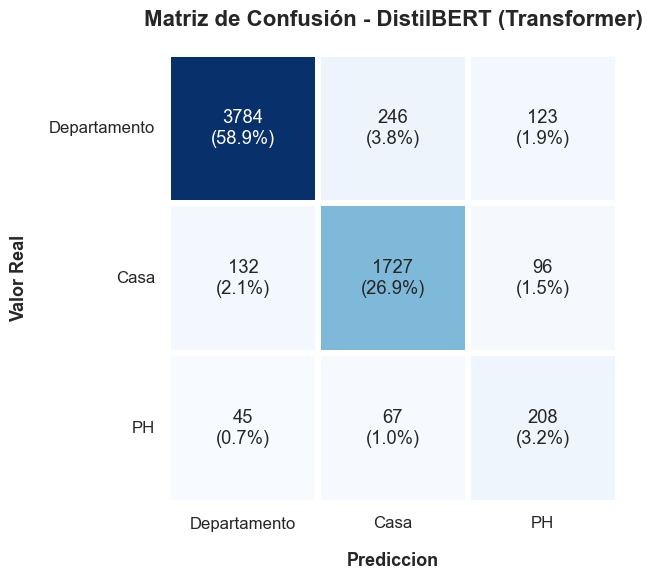

In [5]:
if hay_pesos_locales:
    RUTA_DATOS = RAIZ_PROYECTO / 'data' / 'entrenamiento.csv'
    resumen = relevar_hardware()
    configurar_torch_cpu()
    tamanio_muestra = min(6000, sugerir_tamanio_muestra(resumen.memoria_disponible_gb))

    df_muestra, df_entrenamiento, df_prueba = preparar_corpus_para_modelado(
        ruta_datos=RUTA_DATOS,
        tamanio_muestra=tamanio_muestra,
        tamanio_test=0.2,
        semilla=42,
    )

    etiqueta_a_id, id_a_etiqueta = construir_mapeo_etiquetas(df_muestra['property_type'])
    tokenizador = cargar_tokenizador_transformer()
    modelo = cargar_modelo_transformer_para_clasificacion(
        cantidad_etiquetas=len(etiqueta_a_id),
        etiqueta_a_id=etiqueta_a_id,
        id_a_etiqueta=id_a_etiqueta,
    )

    dl_train, dl_test = crear_dataloaders_transformer(
        df_entrenamiento,
        df_prueba,
        tokenizador,
        etiqueta_a_id=etiqueta_a_id,
        batch_size=4,
        longitud_maxima=128,
    )

    historial = entrenar_transformer_en_cpu(modelo, dl_train, epochs=1)
    display(historial)

    modelo_cuantizado = cuantizar_modelo_dinamicamente(modelo)
    pred_ids = predecir_con_transformer(modelo_cuantizado, dl_test)
    predicciones = [id_a_etiqueta[indice] for indice in pred_ids]

    print("=== Evaluación del Modelo Transformer (DistilBERT) ===")
    print(construir_reporte_clasificacion(df_prueba['property_type'], predicciones))
    display(construir_tabla_metricas(df_prueba['property_type'], predicciones))

    dibujar_matriz_confusion_profesional(
        df_prueba['property_type'],
        predicciones,
        etiquetas_ordenadas=['Departamento', 'Casa', 'PH'],
        titulo='Matriz de Confusión - DistilBERT (Transformer)'
    )
else:
    print("⚠️  No hay pesos locales del modelo.")
    print()
    print("PASOS PARA RESOLVER:")
    print("1. Ejecuta la celda anterior: 'Descargar pesos del modelo'")
    print("2. Luego ejecuta esta celda nuevamente")
    print()
    print("Primera vez: La descarga toma ~2-3 minutos (se cachea automáticamente)")
    print("Siguientes veces: Será instantáneo")

## DistilBERT con Datos Censurados (Sin Data Leakage)
Entrenamos el transformer usando la columna sin las palabras clave.


In [7]:
from src.property_text_pipeline import COLUMNA_TEXTO_LIMPIO_TRANSFORMER_CENSURADO

# Crear dataloaders con texto censurado
dataloader_train_censurado, dataloader_prueba_censurado = crear_dataloaders_transformer(
    df_entrenamiento=df_entrenamiento,
    df_prueba=df_prueba,
    tokenizador=tokenizador,
    etiqueta_a_id=etiqueta_a_id,
    columna_texto=COLUMNA_TEXTO_LIMPIO_TRANSFORMER_CENSURADO,
)

# Cargar un modelo fresco
modelo_censurado = cargar_modelo_transformer_para_clasificacion(
    cantidad_etiquetas=len(etiqueta_a_id),
    etiqueta_a_id=etiqueta_a_id,
    id_a_etiqueta=id_a_etiqueta,
)

if hay_pesos_locales: # Cambiar a True para entrenar localmente o simular
    historial_censurado = entrenar_transformer_en_cpu(
        modelo=modelo_censurado,
        dataloader_entrenamiento=dataloader_train_censurado,
        epochs=1,  # 1 epoca para demostracion
        learning_rate=2e-5
    )

    pred_ids_censurado = predecir_con_transformer(modelo_censurado, dataloader_prueba_censurado)
    predicciones_censurado = [id_a_etiqueta[indice] for indice in pred_ids_censurado]
    print("Transformer Censurado:")
    display(historial_censurado)
    print(construir_reporte_clasificacion(df_prueba['property_type'], predicciones_censurado))
    display(construir_tabla_metricas(df_prueba['property_type'], predicciones_censurado))


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: C:\Users\Federico\.cache\huggingface\hub\models--distilbert-base-multilingual-cased\snapshots\45c032ab32cc946ad88a166f7cb282f58c753c2e
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transformer Censurado:


,epoch,loss_promedio
0,1,0.7177


              precision    recall  f1-score   support

        Casa     0.8937    0.7136    0.7935      1955
Departamento     0.9772    0.7216    0.8302      4153
          PH     0.1506    0.8469    0.2557       320

    accuracy                         0.7254      6428
   macro avg     0.6738    0.7607    0.6265      6428
weighted avg     0.9106    0.7254    0.7904      6428



,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.7254,0.6738,0.7607,0.6265,0.9106,0.7254,0.7904
